# Project Overview

### **Note** : Copy and Run Notebook yourself for Live Interactions

**Geospatial Restaurant Recommendation Engine**

**Objective:** To build a location-based recommendation system that suggests the top restaurants in Tallinn, Estonia, based on a user's exact GPS coordinates, budget constraints, and weighted review scores.

**Methodology:**
1. **Data Cleaning:** Handling missing URLs and standardizing data formats.
2. **Exploratory Data Analysis (EDA):** Geospatial mapping and analyzing categorical distributions.
3. **Feature Engineering:** Creating a weighted composite metric prioritizing Food Quality over Service and Atmosphere.
4. **Heuristic Engine:** Implementing the Haversine formula to calculate real-time shortest-path distances on the Earth's curved surface.





In [1]:
# Core Data Manipulation & Math
import numpy as np 
import pandas as pd 

# Data Visualization
import plotly.express as px
import plotly.graph_objects as go

# Network & Utility Tools
import concurrent.futures
import requests
from tqdm.notebook import tqdm

# Interactive UI & Deployment
import gradio as gr

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/stefannezgoda/tallinn-restaurants-2026/restaraunts_tallinn.csv")

# Data Overview

In [3]:
df.shape

(97, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Restaurant      97 non-null     object 
 1   URL             94 non-null     object 
 2   Address         97 non-null     object 
 3   Cuisine         97 non-null     object 
 4   Price_category  97 non-null     object 
 5   Atmosphere      97 non-null     float64
 6   Food            97 non-null     float64
 7   Service         97 non-null     float64
 8   Weighted_score  97 non-null     float64
 9   Latitude        97 non-null     float64
 10  Longitude       97 non-null     float64
dtypes: float64(6), object(5)
memory usage: 8.5+ KB


In [5]:
df.describe()

,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,4.209278,4.279381,4.169072,4.243299,59.416731,24.788735
std,0.487144,0.425230,0.398006,0.392446,0.150107,0.283567
min,2.400000,1.600000,2.600000,2.080000,58.389640,24.572022
25%,4.000000,4.100000,4.000000,4.080000,59.435863,24.743789
50%,4.300000,4.300000,4.200000,4.280000,59.437705,24.747650
75%,4.600000,4.500000,4.400000,4.500000,59.439840,24.758630
max,4.900000,4.900000,4.800000,4.780000,59.493650,26.717700


In [6]:
df.head()

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,Al Mare Grill,http://www.almarefood.ee/grill/,Mõisa tn 4,american,mid-range,3.5,3.0,3.1,3.12,59.427152,24.655658
1,Allee,https://www.alleerestoran.ee/,Kanuti 2,international,mid-range,4.0,4.1,3.9,4.04,59.440128,24.751131
2,Argentiina Lootsi,https://argentiina.ee/,Lootsi 8,argentinean,expensive,3.3,4.3,3.6,3.96,59.440838,24.765225
3,Argentiina Pärnu mnt,https://argentiina.ee/,Pärnu mnt 37,argentinean,expensive,4.1,4.5,4.2,4.36,59.429272,24.743789
4,Charlies Corner,https://charliescorner.ee/,Juhkentali 28,international,mid-range,3.9,3.9,3.9,3.90,59.427606,24.764699


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Restaurant        0
URL               3
Address           0
Cuisine           0
Price_category    0
Atmosphere        0
Food              0
Service           0
Weighted_score    0
Latitude          0
Longitude         0
dtype: int64

In [9]:
df[df['URL'].isnull()]

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
29,FORK Resto,NaN,Veerenni 24,american,budget,4.5,4.5,4.5,4.50,59.424101,24.748084
67,Burger Box,NaN,Kopli tn 4a,dutch,budget,4.6,4.5,3.8,4.38,59.441590,24.736560
85,Must Puudel,NaN,Kuninga tn 4,international,mid-range,4.6,4.3,4.3,4.36,59.436455,24.745533


In [10]:
# Updating missing urls manually
df.loc[18, 'URL'] = 'https://www.raeharra.ee/en'
df.loc[29, 'URL'] = 'https://www.facebook.com/FORKresto'
df.loc[53, 'URL'] = 'https://www.kolmasdraakon.ee'
df.loc[67, 'URL'] = 'https://www.facebook.com/burgerboxbox/'
df.loc[85, 'URL'] = 'https://www.facebook.com/mustpuudel/'

print(df['URL'].isnull().sum())

0


In [11]:
# Checking URLs working or not
tqdm.pandas(desc="Checking URLs")

def test_url(url):
    if pd.isna(url): 
        return "Missing"
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(url, headers=headers, timeout=5)
        if response.status_code == 200: 
            return "Working"
        else: 
            return f"Broken (Error {response.status_code})"
    except requests.RequestException: 
        return "Broken (Connection Failed)"

def check_urls_concurrently(url_series, max_workers=10):
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(
            executor.map(test_url, url_series), 
            total=len(url_series), 
            desc="Checking URLs Concurrently"
        ))
    return results

df['URL_Status'] = check_urls_concurrently(df['URL'])

print(df['URL_Status'].value_counts())
broken_links = df[df['URL_Status'].str.contains("Broken", na=False)]
display(broken_links[['Restaurant', 'URL', 'URL_Status']])

Checking URLs Concurrently:   0%|          | 0/97 [00:00<?, ?it/s]

URL_Status
Working    97
Name: count, dtype: int64


,Restaurant,URL,URL_Status


# Exploratory Data Analysis

In [12]:
fig = px.scatter_mapbox(
    df, 
    lat="Latitude", 
    lon="Longitude", 
    hover_name="Restaurant",
    hover_data=["Cuisine", "Price_category"], 
    color="Price_category",                 
    zoom=12, 
    height=600,
    title="Tallinn Restaurants by Price Category"
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()



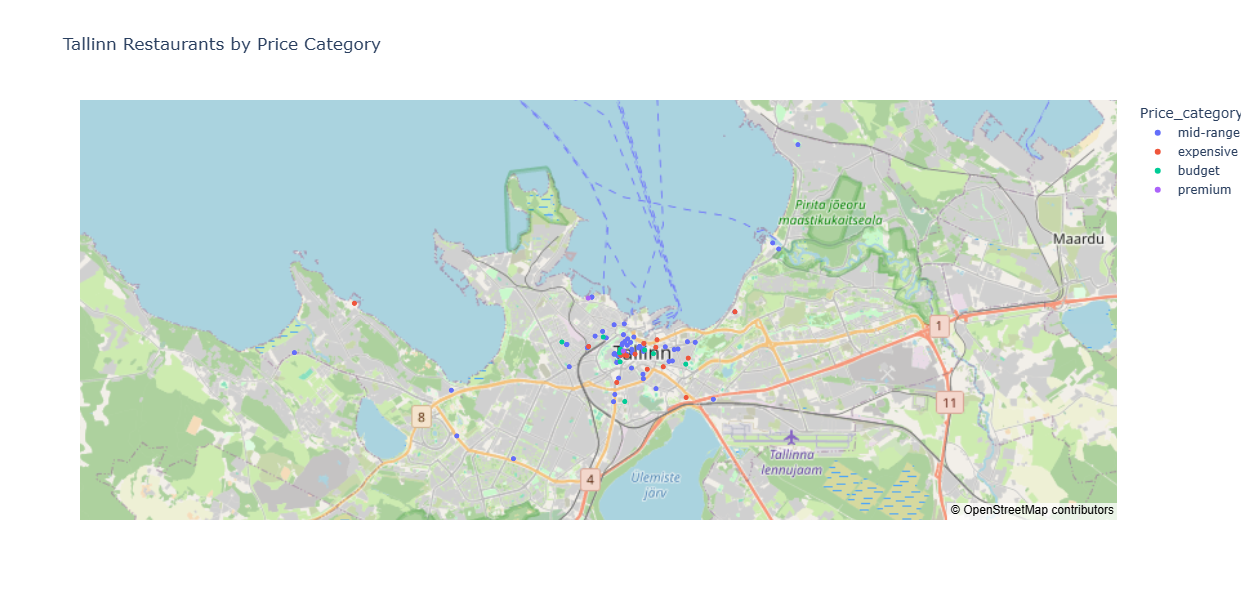

In [13]:
price_counts = df['Price_category'].value_counts().reset_index()
price_counts.columns = ['Price_category', 'Count']

fig_price = px.bar(
    price_counts, 
    x='Price_category', 
    y='Count', 
    title='Number of Restaurants by Price Category',
    color='Price_category',
    text='Count'
)
fig_price.show()

cuisine_counts = df['Cuisine'].value_counts().reset_index().head(10)
cuisine_counts.columns = ['Cuisine', 'Count']

fig_cuisine = px.bar(
    cuisine_counts, 
    x='Cuisine', 
    y='Count',
    title='Top 10 Cuisines in Tallinn',
    text='Count'
)
fig_cuisine.show()

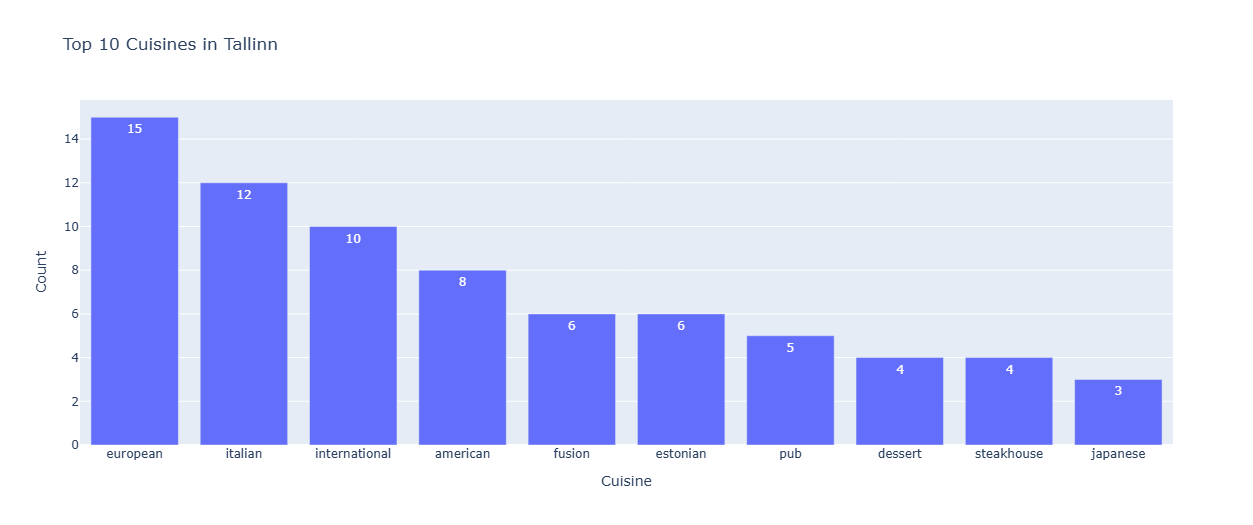
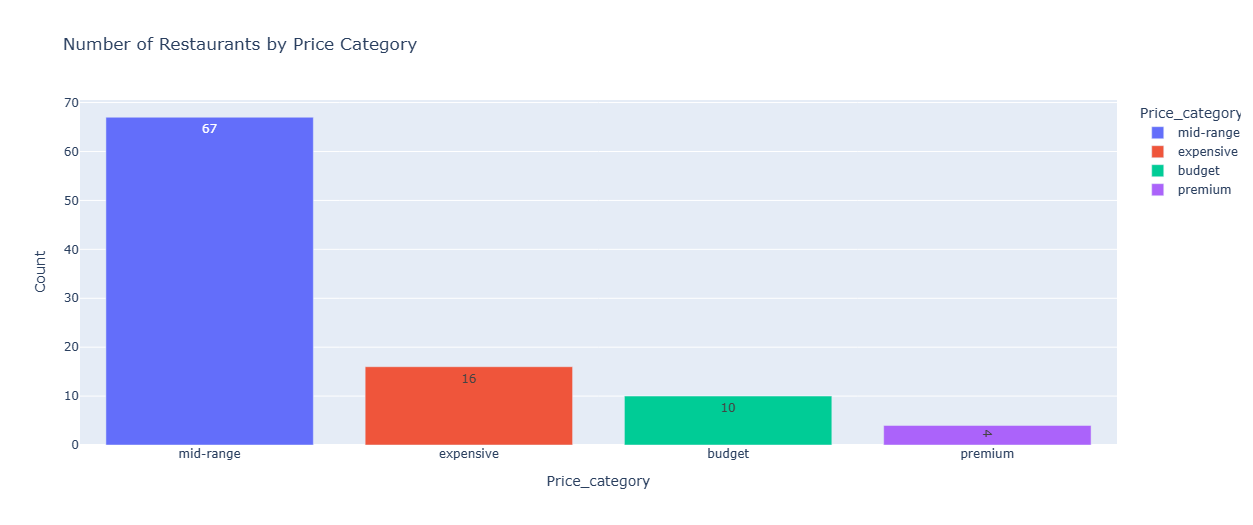

In [14]:
numeric_cols = df[['Food', 'Service', 'Atmosphere', 'Weighted_score']]
corr_matrix = numeric_cols.corr().round(2)

fig_corr = px.imshow(
    corr_matrix, 
    text_auto=True, 
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap: How do Ratings Interact?"
)

fig_corr.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_corr.show()

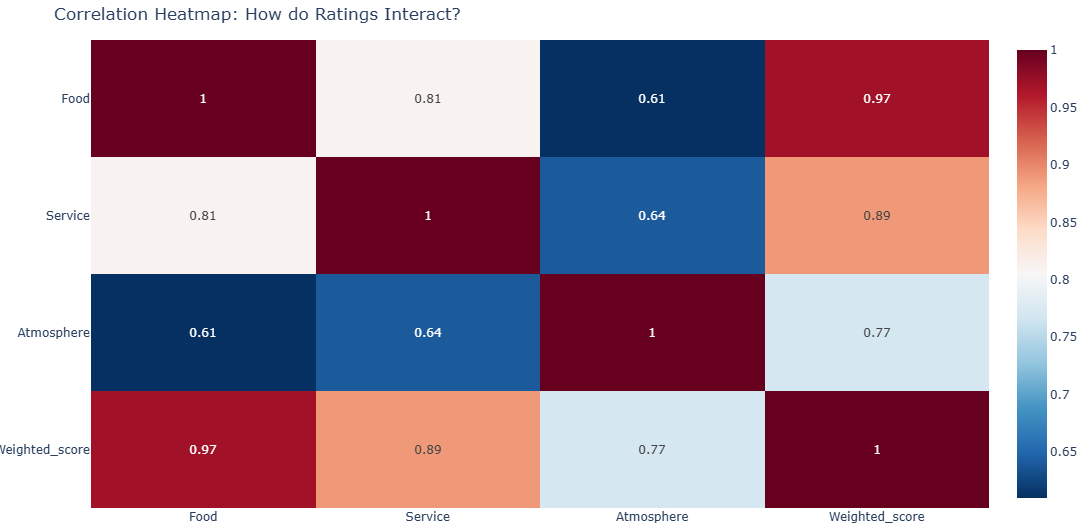

# Feature Engineering

In [15]:
# Define your weights
weight_food = 0.50
weight_service = 0.30
weight_atmosphere = 0.20

# Calculate the weighted rating
df['Overall_Rating'] = (
    (df['Food'] * weight_food) + 
    (df['Service'] * weight_service) + 
    (df['Atmosphere'] * weight_atmosphere)
).round(2)

# Checking the top 5 with the new weighted system
top_5_weighted = df[['Restaurant', 'Overall_Rating', 'Food', 'Service', 'Atmosphere']].sort_values(by='Overall_Rating', ascending=False).head()
display(top_5_weighted)

,Restaurant,Overall_Rating,Food,Service,Atmosphere
24,The Able Butcher,4.77,4.7,4.8,4.9
12,La Prima Pizza Vanalinn,4.75,4.7,4.8,4.8
44,180° by Matthias Diether,4.75,4.8,4.7,4.7
50,Vegan Restoran V,4.75,4.8,4.7,4.7
49,Rataskaevu 16,4.73,4.7,4.8,4.7


In [16]:
fig_rating = px.histogram(
    df, 
    x='Overall_Rating', 
    nbins=20, 
    title='Distribution of Overall Restaurant Ratings',
    color='Price_category',  
    marginal='box',          
    text_auto=True           
)

fig_rating.update_layout(bargap=0.1)
fig_rating.show()

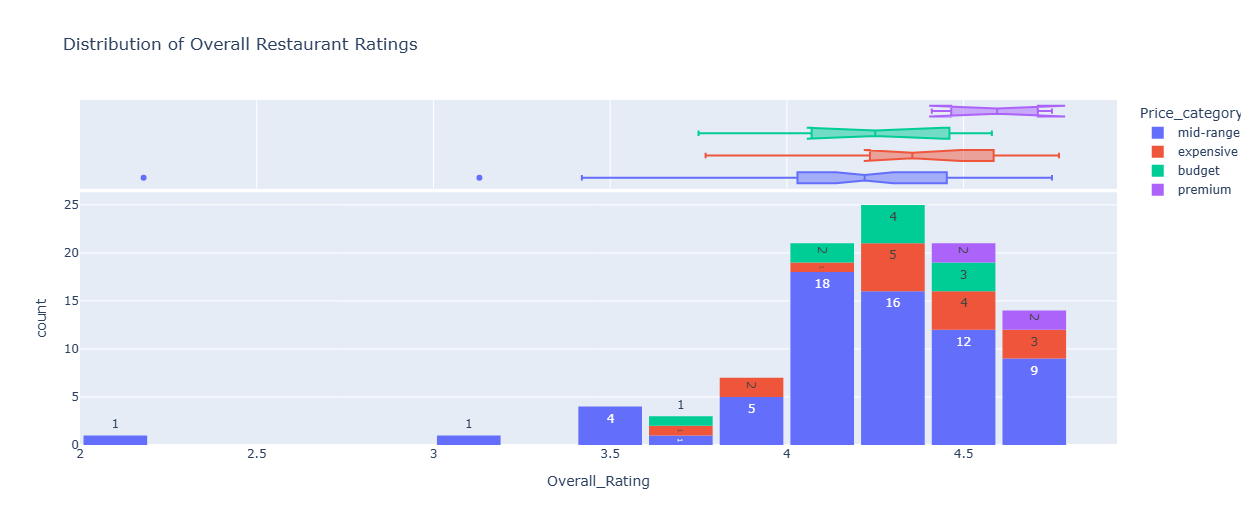

## Distance Calculation (The Haversine Formula)

Because the Earth is a sphere, we cannot use standard straight-line (Euclidean) math to find the distance between two GPS coordinates. Instead, we use the **Haversine formula**, which calculates the shortest distance over the Earth's curved surface. We will vectorize this using `numpy` for maximum performance.

In [17]:
# Calculates the distance in kilometers between a user and a list of locations.
def calculate_distance(user_lat, user_lon, df_lats, df_lons):
    lat1, lon1, lat2, lon2 = map(np.radians, [user_lat, user_lon, df_lats, df_lons])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # radius in kms
    
    return np.round(c * r, 2)

# Test co-ordinates
mock_user_lat = 59.4370
mock_user_lon = 24.7535

# Calculates the distance to all restaurants and save it as a new column
df['Distance_km'] = calculate_distance(mock_user_lat, mock_user_lon, df['Latitude'], df['Longitude'])

# Show the 5 closest restaurants to the user
closest_spots = df[['Restaurant', 'Distance_km', 'Overall_Rating', 'Price_category']].sort_values(by='Distance_km').head()
display(closest_spots)

,Restaurant,Distance_km,Overall_Rating,Price_category
57,Maikrahv,0.00,3.77,expensive
75,Amalfi,0.08,4.35,mid-range
26,Beer Garden,0.17,4.06,mid-range
16,Platz,0.21,4.02,mid-range
81,Frank,0.25,4.07,mid-range


### Example Output

Before wrapping this logic into a user interface, let's look at a sample output. If a user is standing in the center of the Old Town (Lat: 59.4370, Lon: 24.7535) and wants **mid-range** dining, the engine instantly calculates the Haversine distances, ranks the options by their weighted scores, and returns the top 5 closest and best-rated results:

In [18]:
# Returns the top N recommended restaurants based on user location, budget, and weighted ratings.
def recommend_restaurants(user_lat, user_lon, budget_preference, weight_food, weight_service, weight_atm, top_n=10):
    budget_pref_clean = budget_preference.strip().lower()
    filtered_df = df[df['Price_category'].str.strip().str.lower() == budget_pref_clean].copy()
    
    # Handles empty results gracefully
    if filtered_df.empty:
        empty_df = pd.DataFrame(columns=['Restaurant', 'Cuisine', 'Overall_Rating', 'Distance_km', 'URL'])
        return go.Figure(), empty_df
        
    # Calculates the dynamic Overall_Rating
    filtered_df['Overall_Rating'] = (
        (filtered_df['Food'] * weight_food) + 
        (filtered_df['Service'] * weight_service) + 
        (filtered_df['Atmosphere'] * weight_atm)
    ).round(2)
    
    # Calculates distance
    filtered_df['Distance_km'] = calculate_distance(user_lat, user_lon, filtered_df['Latitude'], filtered_df['Longitude'])
    
    # Sort and get Top N
    final_recs = filtered_df.sort_values(by=['Overall_Rating', 'Distance_km'], ascending=[False, True]).head(top_n)
    
    # THE INTERACTIVE MAP 
    fig = px.scatter_mapbox(
        final_recs, 
        lat="Latitude", 
        lon="Longitude", 
        hover_name="Restaurant", 
        hover_data={"Cuisine": True, "Overall_Rating": True, "Distance_km": True, "Latitude": False, "Longitude": False},
        color="Overall_Rating",
        color_continuous_scale=px.colors.sequential.Plasma,
        zoom=13, 
        title="Top Recommended Spots Near You"
    )
    
    # Adds a custom red marker for the User's Location
    fig.add_trace(go.Scattermapbox(
        lat=[user_lat],
        lon=[user_lon],
        mode='markers+text',
        marker=go.scattermapbox.Marker(size=14, color='red'),
        text=["📍 YOU ARE HERE"],
        textposition="bottom right",
        name="Your Location"
    ))
    
    fig.update_layout(mapbox_style="open-street-map", margin={"r":0,"t":40,"l":0,"b":0})
    
    # Prepares the clean table output
    display_df = final_recs[['Restaurant', 'Cuisine', 'Overall_Rating', 'Distance_km', 'URL']]
    
    # Returns both the Map and the Table!
    return fig, display_df

# Interactive Deployment (Gradio)

To make this algorithm accessible to end-users, the underlying logic has been wrapped in a Gradio UI. The interface allows users to input their current coordinates and budget, instantly triggering the backend Haversine calculations and returning the sorted Top 10 recommendations.

In [19]:
# Dictionary of popular Tallinn locations for quick selection
neighborhoods = {
    "Old Town (Center)": (59.4370, 24.7535),
    "Telliskivi (Creative City)": (59.4398, 24.7295),
    "Kadriorg (Park & Palace)": (59.4385, 24.7880),
    "Noblessner (Marina)": (59.4526, 24.7345),
    "Custom Location": (59.4370, 24.7535)
}

# Helper function to update coordinates when a user picks a preset
def update_coordinates(neighborhood):
    lat, lon = neighborhoods.get(neighborhood, (59.4370, 24.7535))
    return lat, lon

# Building the Custom Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Tallinn Restaurant Recommender")
    gr.Markdown("Find the best dining spots in Tallinn based on your location, budget, and personal preferences.")
    
    with gr.Row():
        # LEFT SIDEBAR(Inputs)
        with gr.Column(scale=1):
            gr.Markdown("### 1. Your Location")
            preset_dropdown = gr.Dropdown(
                choices=list(neighborhoods.keys()), 
                value="Old Town (Center)", 
                label="Quick Select Neighborhood"
            )
            
            with gr.Row():
                user_lat = gr.Number(value=59.4370, label="Latitude")
                user_lon = gr.Number(value=24.7535, label="Longitude")
                
            gr.Markdown("### 2. Your Preferences")
            budget = gr.Dropdown(choices=['budget', 'mid-range', 'expensive', 'premium'], value='mid-range', label="Budget")
            weight_food = gr.Slider(0, 1, value=0.50, step=0.05, label="Weight: Food Quality")
            weight_service = gr.Slider(0, 1, value=0.30, step=0.05, label="Weight: Service Quality")
            weight_atm = gr.Slider(0, 1, value=0.20, step=0.05, label="Weight: Atmosphere")
            
            submit_btn = gr.Button("Find Restaurants 🔍", variant="primary")
            
        # RIGHT MAIN AREA (Outputs)
        with gr.Column(scale=2):
            map_output = gr.Plot(label="Interactive Map")
            table_output = gr.Dataframe(headers=['Restaurant', 'Cuisine', 'Rating', 'Distance (km)', 'URL'], label="Detailed Results")
            
    # INTERACTIVITY LOGIC
    # When the dropdown changes, update the Latitude and Longitude number fields
    preset_dropdown.change(
        fn=update_coordinates,
        inputs=[preset_dropdown],
        outputs=[user_lat, user_lon]
    )
    
    # When the button is clicked, run the recommendation function
    submit_btn.click(
        fn=recommend_restaurants,
        inputs=[user_lat, user_lon, budget, weight_food, weight_service, weight_atm],
        outputs=[map_output, table_output]
    )

# Launch the app
demo.launch(inline=True, share=True, height=850)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f273d17311d82703c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion & Future Work

This notebook demonstrates a highly efficient, deterministic, rule-based recommendation system. Because it relies on strict mathematical heuristics rather than complex model inference, it is incredibly fast and perfectly accurate for localized searches.

**Future Enhancements (Machine Learning):**

* If this dataset were expanded to include historical user-review logs, the next iteration of this project would involve transitioning from a rule-based engine to an AI-driven one. Specifically, we could implement **Collaborative Filtering** (via Matrix Factorization) to predict user preferences based on similar users' behavioral patterns, or integrate a **Retrieval-Augmented Generation (RAG)** chatbot to allow users to interact with the database via natural language processing.